In [1]:
# Clone the repository
!git clone https://github.com/qwedrfgvbnvgfdrew/Capstone-Project.git

Cloning into 'Capstone-Project'...
remote: Enumerating objects: 241, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 241 (delta 52), reused 2 (delta 2), pack-reused 151 (from 1)
Receiving objects: 100% (241/241), 1.56 MiB | 10.90 MiB/s, done.
Resolving deltas: 100% (82/82), done.


In [2]:
import os

# Define the repository root. Assuming it's cloned to /content/
REPO_ROOT = '/content/Capstone-Project'

# Create the reports/figures directory if it doesn't exist
os.makedirs(os.path.join(REPO_ROOT, "reports", "figures"), exist_ok=True)
print(f"Repository root set to: {REPO_ROOT}")
print(f"Ensured figures directory exists at: {os.path.join(REPO_ROOT, 'reports', 'figures')}")

Repository root set to: /content/Capstone-Project
Ensured figures directory exists at: /content/Capstone-Project/reports/figures


# 01 — Exploratory Data Analysis
### EDU-01: Student Learning Segmentation

This notebook explores the **xAPI-Edu-Data** dataset before any modeling
decisions are made. It exists to justify the preprocessing choices used in
`src/preprocessing.py` and `src/train.py` — every decision made there (which
columns to drop, why standardization is needed, etc.) is grounded in a
finding from this notebook.

Run this notebook from the **repository root** (so relative paths resolve),
or in Google Colab after cloning the repository (see `demo.ipynb`).

In [3]:
import sys, os
sys.path.insert(0, REPO_ROOT)  # allow `import src.*` from the repo root

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw_data, basic_quality_checks, CATEGORICAL_FEATURES, BEHAVIOR_NUMERIC_FEATURES

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

DATA_PATH = os.path.join(REPO_ROOT, "data", "xAPI-Edu-Data.csv")
df = load_raw_data(DATA_PATH)
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


## 1. Basic shape, dtypes, and data-quality checks

In [ ]:
print(f"Shape: {df.shape}")
print()
print(df.dtypes)

Shape: (480, 17)

gender                      object
NationalITy                 object
PlaceofBirth                object
StageID                     object
GradeID                     object
SectionID                   object
Topic                       object
Semester                    object
Relation                    object
raisedhands                  int64
VisITedResources             int64
AnnouncementsView            int64
Discussion                   int64
ParentAnsweringSurvey       object
ParentschoolSatisfaction    object
StudentAbsenceDays          object
Class                       object
dtype: object


In [ ]:
quality = basic_quality_checks(df)
quality

{'n_rows': 480,
 'n_columns': 17,
 'n_duplicate_rows': 2,
 'n_missing_values_total': 0,
 'class_distribution': {'M': 211, 'H': 142, 'L': 127}}

**Finding:** 480 rows, 17 columns, **zero missing values**, **zero duplicate
rows**. This matches the Capstone Brief's statement that "the dataset
contains no missing values." No imputation is required anywhere in the
pipeline.

## 2. Target-for-interpretation-only: `Class` distribution

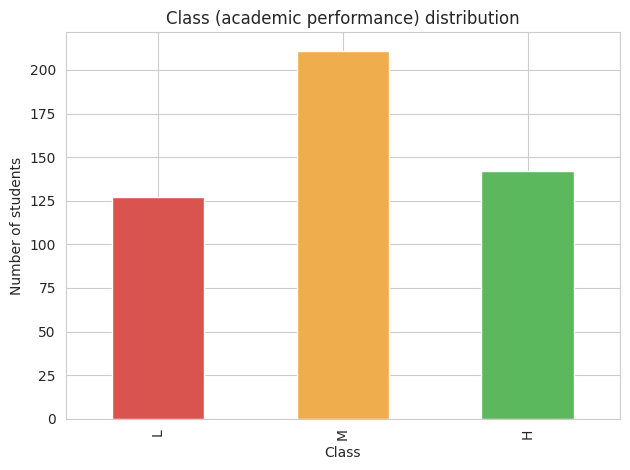

,count
Class,
M,211
H,142
L,127


In [4]:
ax = df["Class"].value_counts().reindex(["L", "M", "H"]).plot(kind="bar", color=["#d9534f", "#f0ad4e", "#5cb85c"])
ax.set_title("Class (academic performance) distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of students")
plt.tight_layout()
plt.savefig(os.path.join(REPO_ROOT, "reports", "figures", "eda_class_distribution.png"), dpi=150)
plt.show()
df["Class"].value_counts()

**Finding:** Classes are reasonably balanced (not extreme), but this
variable is **not** used for clustering — it is excluded from every feature
matrix built in `src/preprocessing.py` and is only reintroduced afterward, in
`src/train.py`, to interpret the discovered clusters (see the Capstone
Brief's leakage-risk discussion).

## 3. Distributions of the four behavioral features used for clustering

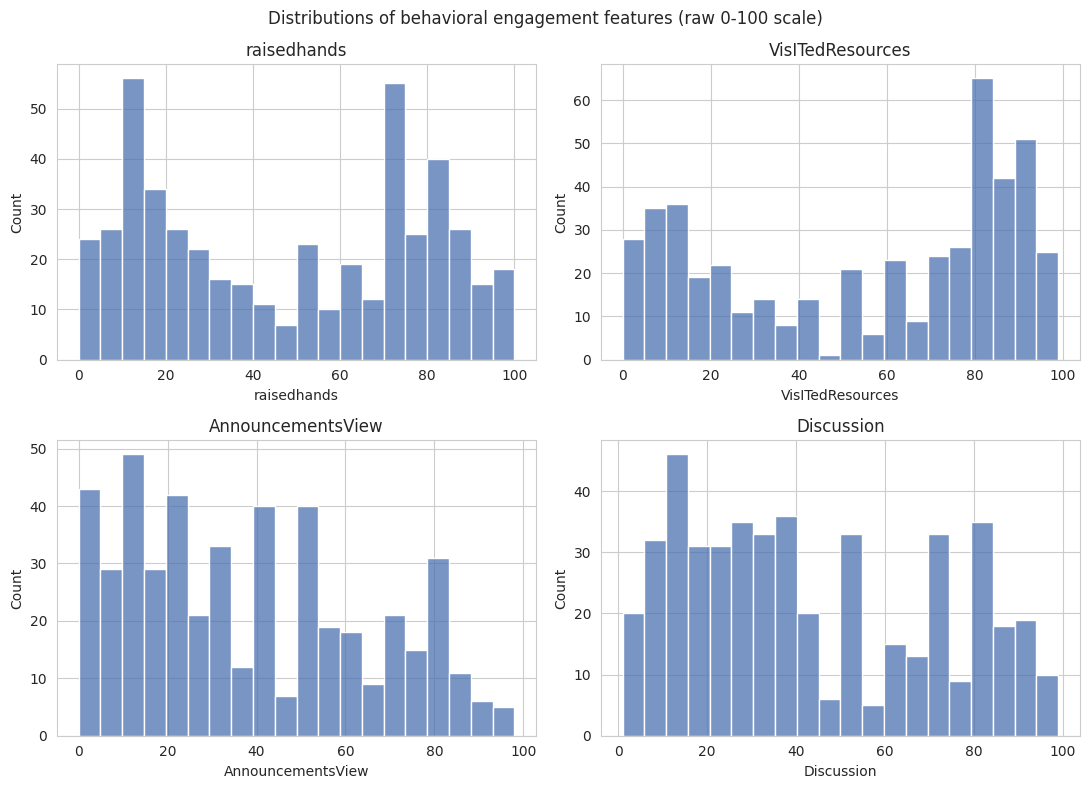

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, BEHAVIOR_NUMERIC_FEATURES):
    sns.histplot(df[col], bins=20, ax=ax, color="#4c72b0")
    ax.set_title(col)
plt.suptitle("Distributions of behavioral engagement features (raw 0-100 scale)")
plt.tight_layout()
plt.savefig(os.path.join(REPO_ROOT, "reports", "figures", "eda_behavior_distributions.png"), dpi=150)
plt.show()

**Finding:** all four behavioral features are on a comparable raw 0-100
scale already, but their *shapes* differ (e.g. `Discussion` is more
right-skewed than `VisITedResources`) and their *spreads* (standard
deviations) differ too — this is exactly why `StandardScaler` is applied
before any distance-based clustering algorithm (K-Means, Agglomerative,
DBSCAN all rely on Euclidean distance, which is dominated by whichever
feature happens to have the largest variance if left unscaled).

## 4. Correlation among the behavioral features

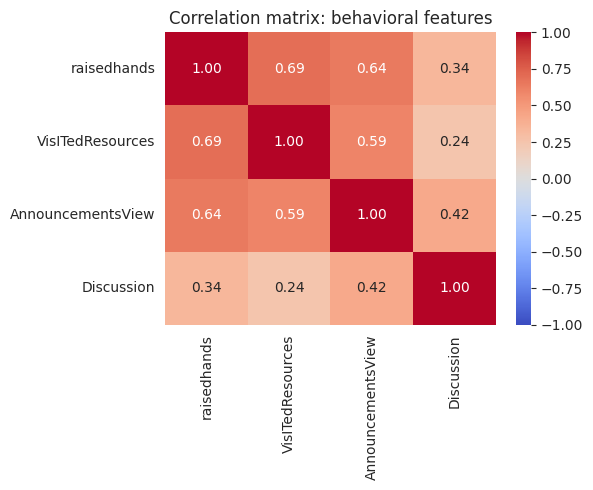

,raisedhands,VisITedResources,AnnouncementsView,Discussion
raisedhands,1.000000,0.691572,0.643918,0.339386
VisITedResources,0.691572,1.000000,0.594500,0.243292
AnnouncementsView,0.643918,0.594500,1.000000,0.417290
Discussion,0.339386,0.243292,0.417290,1.000000


In [6]:
corr = df[BEHAVIOR_NUMERIC_FEATURES].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix: behavioral features")
plt.tight_layout()
plt.savefig(os.path.join(REPO_ROOT, "reports", "figures", "eda_behavior_correlation.png"), dpi=150)
plt.show()
corr

**Finding:** `raisedhands` and `VisITedResources` are fairly strongly
correlated, and `raisedhands`/`Discussion` show a moderate correlation too —
consistent with the Capstone Brief's own note that *"some features may be
correlated (e.g., RaisedHands and Discussion)."* All four are kept, however,
because none of the pairs are so close to collinear (no pair exceeds ~0.7)
that one is purely redundant information, and each measures a genuinely
different engagement channel (participation vs. resource use vs. passive
announcement-checking vs. discussion-board activity).

## 5. Redundant demographic column: `PlaceofBirth` vs. `NationalITy`

In [ ]:
# The Capstone Brief calls out "highly correlated variables" as a preprocessing
# concern. PlaceofBirth is not one of the behavioral features, but it is a
# near-duplicate of NationalITy in this dataset -- let's check.
match_rate = df["NationalITy"].eq(df["PlaceofBirth"]).mean()
print(f"Exact string match rate between NationalITy and PlaceofBirth: {match_rate:.1%}")
pd.crosstab(df["NationalITy"], df["PlaceofBirth"]).iloc[:6, :6]  # preview, not exact match due to naming differences

Exact string match rate between NationalITy and PlaceofBirth: 51.7%


PlaceofBirth,Egypt,Iran,Iraq,Jordan,KuwaIT,Lybia
NationalITy,,,,,,
Egypt,8,0,0,0,1,0
Iran,0,6,0,0,0,0
Iraq,0,0,22,0,0,0
Jordan,1,0,0,152,1,0
KW,0,0,0,0,177,0
Lybia,0,0,0,0,0,6


In [ ]:
# A stricter check: for each NationalITy, how many DISTINCT PlaceofBirth values occur?
distinct_places_per_nationality = df.groupby("NationalITy")["PlaceofBirth"].nunique()
distinct_places_per_nationality.sort_values(ascending=False)

NationalITy
Jordan         7
Tunis          4
KW             2
Syria          2
Palestine      2
Egypt          2
lebanon        2
SaudiArabia    2
Iran           1
Iraq           1
Lybia          1
Morocco        1
USA            1
venzuela       1
Name: PlaceofBirth, dtype: int64

**Finding:** most nationalities map to a single (or very small number of)
distinct `PlaceofBirth` values — the two columns carry almost the same
information. To avoid feeding a highly redundant categorical pair into the
one-hot encoding (which would silently double-weight the same real-world
signal in the distance calculation K-Means relies on), **`PlaceofBirth` is
dropped** in `src/preprocessing.py`, keeping only `NationalITy`. This is a
documented feature-selection decision, not an oversight.

## 6. Categorical feature cardinality (relevant for one-hot encoding)

In [ ]:
cardinality = df[CATEGORICAL_FEATURES].nunique().sort_values(ascending=False)
cardinality

NationalITy                 14
Topic                       12
GradeID                     10
SectionID                    3
StageID                      3
gender                       2
Semester                     2
Relation                     2
StudentAbsenceDays           2
ParentAnsweringSurvey        2
ParentschoolSatisfaction     2
dtype: int64

**Finding:** cardinality is modest across all categorical features (the
largest, `NationalITy`, has well under 20 categories), so one-hot encoding
is a reasonable, tractable choice — it will not blow up the feature space
into hundreds of columns.

## 7. Behavioral features vs. Class (exploratory only — Class is not used for clustering)

/tmp/ipykernel_580/1261120872.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y=col, order=["L", "M", "H"], ax=ax, palette=["#d9534f", "#f0ad4e", "#5cb85c"])
/tmp/ipykernel_580/1261120872.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y=col, order=["L", "M", "H"], ax=ax, palette=["#d9534f", "#f0ad4e", "#5cb85c"])
/tmp/ipykernel_580/1261120872.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y=col, order=["L", "M", "H"], ax=ax, palette=["#d9534f", "#f0ad4e", "#5cb85c"])
/

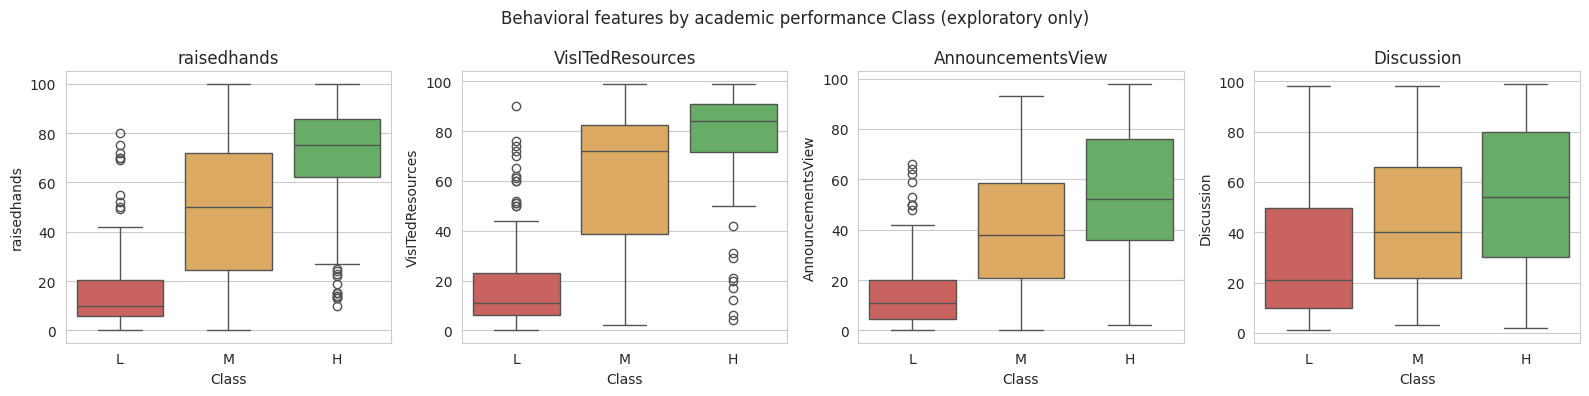

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, BEHAVIOR_NUMERIC_FEATURES):
    sns.boxplot(data=df, x="Class", y=col, order=["L", "M", "H"], ax=ax, palette=["#d9534f", "#f0ad4e", "#5cb85c"])
    ax.set_title(col)
plt.suptitle("Behavioral features by academic performance Class (exploratory only)")
plt.tight_layout()
plt.savefig(os.path.join(REPO_ROOT, "reports", "figures", "eda_behavior_by_class.png"), dpi=150)
plt.show()

**Finding:** students in the "L" (Low) performance class visibly show
lower engagement across all four behavioral features than "H" (High)
students. This is purely exploratory context — it is **not** used to select
features or tune the clustering model — but it's a useful sanity check that
behavioral engagement and academic outcome are related in this dataset,
which is why we later use `Class` as a **post-hoc interpretation aid** for
the discovered clusters (see `notebooks/02_experiments.ipynb` and
`reports/results.md`).

## 8. Summary of EDA-driven decisions

| Finding | Decision made in `src/preprocessing.py` |
|---|---|
| No missing values, no duplicates | No imputation or de-duplication needed |
| Behavioral features share a 0-100 scale but different variances | `StandardScaler` applied before clustering |
| `PlaceofBirth` is redundant with `NationalITy` | `PlaceofBirth` dropped from the feature set |
| Categorical cardinality is modest | One-hot encoding used (no target/mean encoding needed) |
| `Class` correlates with engagement but is an outcome, not a behavior | `Class` excluded from clustering; used only for post-hoc interpretation |
